In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/archive/NFL Play by Play 2009-2018 (v5).csv")

/var/folders/87/k687kh2n1r377mqzh_gtkssr0000gn/T/ipykernel_33784/1535347164.py:1: DtypeWarning: Columns (42,166,167,168,169,174,175,178,179,182,183,188,189,190,191,194,195,203,204,205,218,219,220,231,232,233,238,240,241,249) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/evansmith/Desktop/ds-studio-ii/archive/NFL Play by Play 2009-2018 (v5).csv")


In [4]:
df["desc"].isnull().sum()

np.int64(2)

In [5]:
df.shape

(449371, 255)

In [6]:
df.head()

,play_id,game_id,home_team,away_team,posteam,posteam_type,defteam,side_of_field,yardline_100,game_date,...,penalty_player_id,penalty_player_name,penalty_yards,replay_or_challenge,replay_or_challenge_result,penalty_type,defensive_two_point_attempt,defensive_two_point_conv,defensive_extra_point_attempt,defensive_extra_point_conv
0,46,2009091000,PIT,TEN,PIT,home,TEN,TEN,30.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
1,68,2009091000,PIT,TEN,PIT,home,TEN,PIT,58.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
2,92,2009091000,PIT,TEN,PIT,home,TEN,PIT,53.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
3,113,2009091000,PIT,TEN,PIT,home,TEN,PIT,56.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0
4,139,2009091000,PIT,TEN,PIT,home,TEN,PIT,56.0,2009-09-10,...,NaN,NaN,NaN,0,NaN,NaN,0.0,0.0,0.0,0.0


In [29]:
df["field_goal_result"].value_counts()

field_goal_result
made       8226
missed     1381
blocked     206
Name: count, dtype: int64

In [35]:
field_goal_missed1 = df[df["field_goal_result"] == "missed"]
field_goal_blocked = df[df["field_goal_result"] == "blocked"]
field_goal_made = df[df["field_goal_result"] == "made"]

In [36]:
field_goal_missed1.shape

(1381, 255)

In [37]:
field_goal_blocked.shape

(206, 255)

In [38]:
field_goal_made.shape

(8226, 255)

In [39]:
# Combined missed and blocked to made one missed variable

field_goal_missed = field_goal_missed1 + field_goal_blocked
field_goal_missed.shape

(1587, 255)

In [47]:
# Sorted through to find number of timeouts called from 2009-2018 in the NFL

timeout = df["timeout"]

In [14]:
df.columns

Index(['play_id', 'game_id', 'home_team', 'away_team', 'posteam',
       'posteam_type', 'defteam', 'side_of_field', 'yardline_100', 'game_date',
       ...
       'penalty_player_id', 'penalty_player_name', 'penalty_yards',
       'replay_or_challenge', 'replay_or_challenge_result', 'penalty_type',
       'defensive_two_point_attempt', 'defensive_two_point_conv',
       'defensive_extra_point_attempt', 'defensive_extra_point_conv'],
      dtype='object', length=255)

In [15]:
# This sorts through the description column to find every time an opposing team calls a timeout before 
# the other team attempts a field goal. 

count = 0
for i in range(len(df) - 1):
    if (
        df.loc[i, "game_id"] == df.loc[i + 1, "game_id"] and
        df.loc[i, "timeout"] == 1 and
        df.loc[i + 1, "play_type"] == "field_goal"
    ):
        description = df.loc[i, "desc"]
        if "Timeout" in description and " by " in description:
            timeout_team = description.split(" by ")[1].split(" ")[0]
            defending_team = df.loc[i + 1, "defteam"]
            if timeout_team == defending_team:
                count += 1

print(count)

592


In [16]:
# Sorts through the data set to find how many of those 592 kicks after timeouts were made and missed

iced_made = 0
iced_missed = 0

for i in range(len(df) - 1):
    if (
        df.loc[i, "game_id"] == df.loc[i + 1, "game_id"] and
        df.loc[i, "timeout"] == 1 and
        df.loc[i + 1, "play_type"] == "field_goal"
    ):
        desc_timeout = df.loc[i, "desc"]
        if "Timeout" in desc_timeout and " by " in desc_timeout:
            timeout_team = desc_timeout.split(" by ")[1].split(" ")[0]
            defending_team = df.loc[i + 1, "defteam"]
            if timeout_team == defending_team:
                desc_kick = df.loc[i + 1, "desc"]
                if "field goal is GOOD" in desc_kick:
                    iced_made += 1
                elif "field goal is No Good" in desc_kick or "field goal is BLOCKED" in desc_kick:
                    iced_missed += 1

iced_total = iced_made + iced_missed

print(iced_made)
print(iced_missed)
print(iced_total)

455
137
592


In [17]:
# Sorts through the data set to find how many field goals that were not iced by the oposing team were made and missed

non_iced_made = 0
non_iced_missed = 0

for i in range(len(df) - 1):
    if df.loc[i, "play_type"] == "field_goal":
        # Check if the previous play was an opposing timeout (i.e. iced)
        prev_is_icing = (
            df.loc[i - 1, "game_id"] == df.loc[i, "game_id"] and
            df.loc[i - 1, "timeout"] == 1 and
            "Timeout" in str(df.loc[i - 1, "desc"]) and
            " by " in str(df.loc[i - 1, "desc"]) and
            df.loc[i - 1, "desc"].split(" by ")[1].split(" ")[0] == df.loc[i, "defteam"]
        )
        if not prev_is_icing:
            desc_kick = df.loc[i, "desc"]
            if "field goal is GOOD" in desc_kick:
                non_iced_made += 1
            elif "field goal is No Good" in desc_kick or "field goal is BLOCKED" in desc_kick:
                non_iced_missed += 1

non_iced_total = non_iced_made + non_iced_missed
print(non_iced_made)
print(non_iced_missed)
print(non_iced_total)

7750
1434
9184


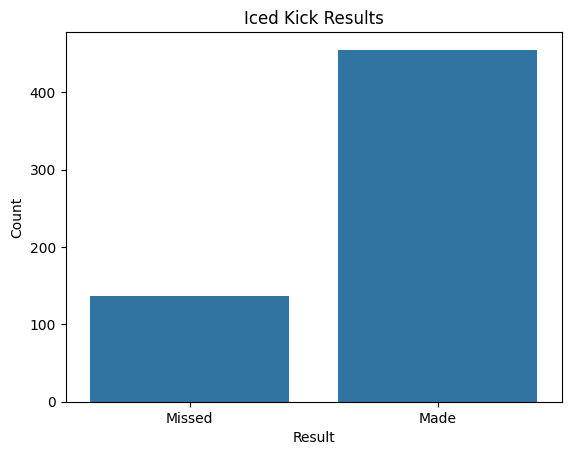

In [18]:
# Barplot of iced kicks

iced_df = pd.DataFrame({
    "Result": ["Missed", "Made"],
    "Count": [iced_missed, iced_made]
})

sns.barplot(x="Result", y="Count", data=iced_df)
plt.title("Iced Kick Results")
plt.show()

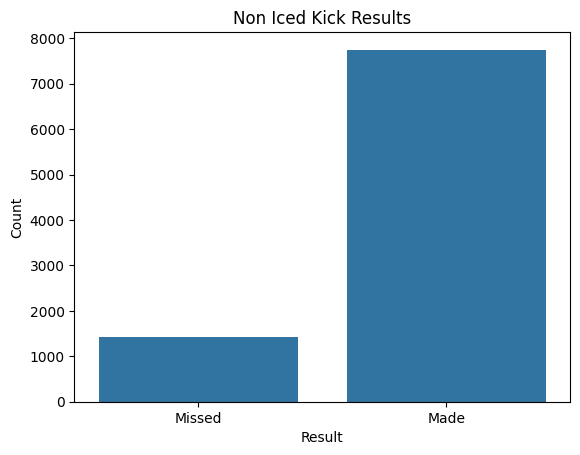

In [19]:
# Barplot of non iced kicks

non_iced_df = pd.DataFrame({
    "Result": ["Missed", "Made"],
    "Count": [non_iced_missed, non_iced_made]
})

sns.barplot(x="Result", y="Count", data=non_iced_df)
plt.title("Non Iced Kick Results")
plt.show()

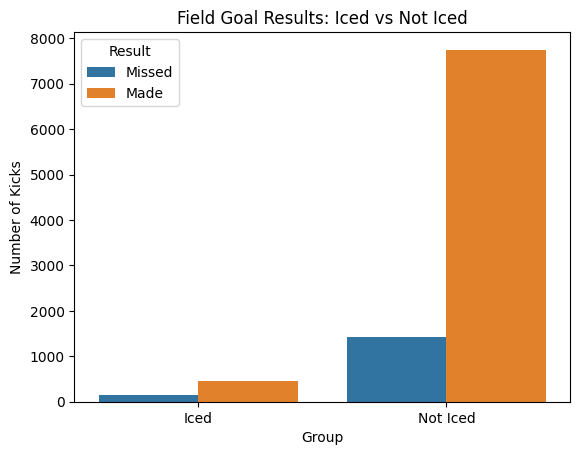

In [20]:
# Barplot of Iced and Not Iced combined 

data = pd.DataFrame({
    "Group": ["Iced", "Iced", "Not Iced", "Not Iced"],
    "Result": ["Missed", "Made", "Missed", "Made"],
    "Count": [iced_missed, iced_made, non_iced_missed, non_iced_made]
})

sns.barplot(data=data, x="Group", y="Count", hue="Result")

plt.title("Field Goal Results: Iced vs Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

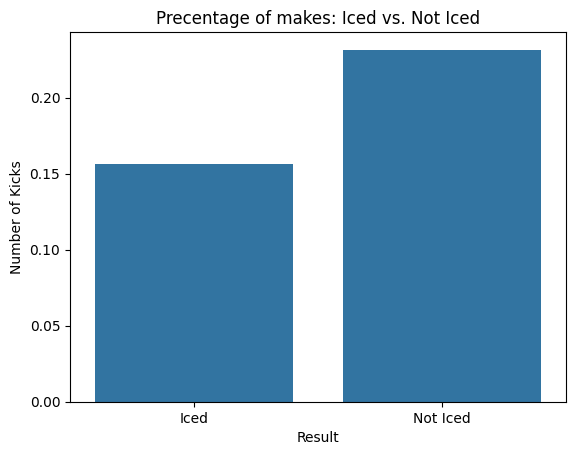

In [21]:
# Barplot of precentage of iced vs not iced kicks missed

data = pd.DataFrame({
    "Result": ["Iced", "Not Iced"],
    "Count": [(non_iced_missed / non_iced_total), (iced_missed / iced_total)]
})

sns.barplot(data=data, x="Result", y="Count")

plt.title("Precentage of makes: Iced vs. Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

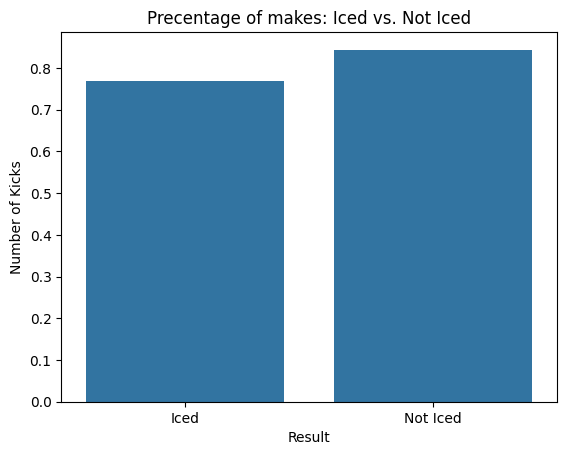

In [22]:
# Barplot of precentage of iced vs not iced kicks made

data = pd.DataFrame({
    "Result": ["Iced", "Not Iced"],
    "Count": [(iced_made / iced_total), (non_iced_made / non_iced_total)]
})

sns.barplot(data=data, x="Result", y="Count")

plt.title("Precentage of makes: Iced vs. Not Iced")
plt.ylabel("Number of Kicks")
plt.show()

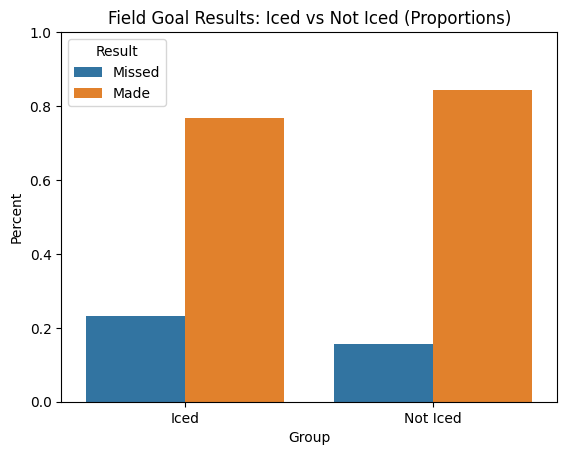

In [23]:
# Barplot of precentage of iced vs not iced combined

iced_total = iced_made + iced_missed
non_iced_total = non_iced_made + non_iced_missed

data_percent = pd.DataFrame({
    "Group": ["Iced", "Iced", "Not Iced", "Not Iced"],
    "Result": ["Made", "Missed", "Made", "Missed"],
    "Percent": [
        iced_made / iced_total,
        iced_missed / iced_total,
        non_iced_made / non_iced_total,
        non_iced_missed / non_iced_total
    ]
})

sns.barplot(
    data=data_percent,
    x="Group",
    y="Percent",
    hue="Result",
    hue_order=["Missed", "Made"]
)

plt.ylim(0,1)
plt.title("Field Goal Results: Iced vs Not Iced (Proportions)")
plt.show()

In [24]:
from statsmodels.stats.proportion import proportions_ztest

In [25]:
# Since the p-value is less than .05 I can conclude that icing the kicker is statistically significant and works in the NFL from 2009-2018.

stat, pval = proportions_ztest([iced_missed, non_iced_missed], [(iced_made + iced_missed), (non_iced_made + non_iced_missed)])
print('{0:0.10f}'.format(pval))

0.0000013389
